#Train set

##Import required libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import classification_report, accuracy_score, log_loss
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

##Upload Dataset

In [5]:
df = pd.read_csv('/kaggle/input/competitions/multiclassificationtask/train.csv', index_col = 0)
df

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
id,,,,,,,,,,,,,,,,,,,
0,2178.0,D-penicillamine,16374.0,F,N,N,N,N,0.5,263.0,3.20,43.0,1110.0,106.95,67.0,430.0,9.6,3.0,C
1,2644.0,D-penicillamine,17774.0,F,N,N,N,N,0.8,280.0,3.60,22.0,678.0,62.00,80.0,427.0,13.0,3.0,C
2,3069.0,Placebo,17844.0,F,N,N,N,N,1.1,408.0,4.40,54.0,2108.0,142.60,137.0,203.0,10.6,3.0,C
3,2216.0,Placebo,19221.0,F,N,Y,Y,N,0.8,252.0,3.70,36.0,843.0,55.80,56.0,336.0,9.6,4.0,C
4,2256.0,Placebo,21600.0,F,N,N,N,N,4.7,348.0,3.06,464.0,961.0,120.90,146.0,298.0,11.0,2.0,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,1783.0,Placebo,23107.0,F,N,Y,N,S,1.3,243.0,3.76,58.0,944.0,97.00,93.0,233.0,9.9,4.0,C
14996,3492.0,NaN,13149.0,F,NaN,NaN,NaN,N,0.7,NaN,4.03,NaN,NaN,NaN,NaN,273.0,10.3,2.0,C
14997,1170.0,NaN,22646.0,F,NaN,NaN,NaN,N,0.8,NaN,3.14,NaN,NaN,NaN,NaN,280.0,10.6,3.0,C


In [14]:
df.info(

)

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         15000 non-null  float64
 1   Drug           8494 non-null   object 
 2   Age            15000 non-null  float64
 3   Sex            15000 non-null  object 
 4   Ascites        8502 non-null   object 
 5   Hepatomegaly   8492 non-null   object 
 6   Spiders        8491 non-null   object 
 7   Edema          15000 non-null  object 
 8   Bilirubin      15000 non-null  float64
 9   Cholesterol    6701 non-null   float64
 10  Albumin        15000 non-null  float64
 11  Copper         8399 non-null   float64
 12  Alk_Phos       8488 non-null   float64
 13  SGOT           8486 non-null   float64
 14  Tryglicerides  6666 non-null   float64
 15  Platelets      14436 non-null  float64
 16  Prothrombin    14984 non-null  float64
 17  Stage          15000 non-null  float64
 18  Status     

##Data preprocessing

In [49]:
df.duplicated().sum()

np.int64(6)

In [6]:
df.drop_duplicates(inplace=True)

In [52]:
df.isnull().sum()

N_Days              0
Drug             6500
Age                 0
Sex                 0
Ascites          6492
Hepatomegaly     6502
Spiders          6503
Edema               0
Bilirubin           0
Cholesterol      8293
Albumin             0
Copper           6595
Alk_Phos         6506
SGOT             6508
Tryglicerides    8328
Platelets         564
Prothrombin        16
Stage               0
Status              0
dtype: int64

In [7]:
df.drop(index = df[df['Status'] == 'Y'].index, inplace=True)

##Visualisation

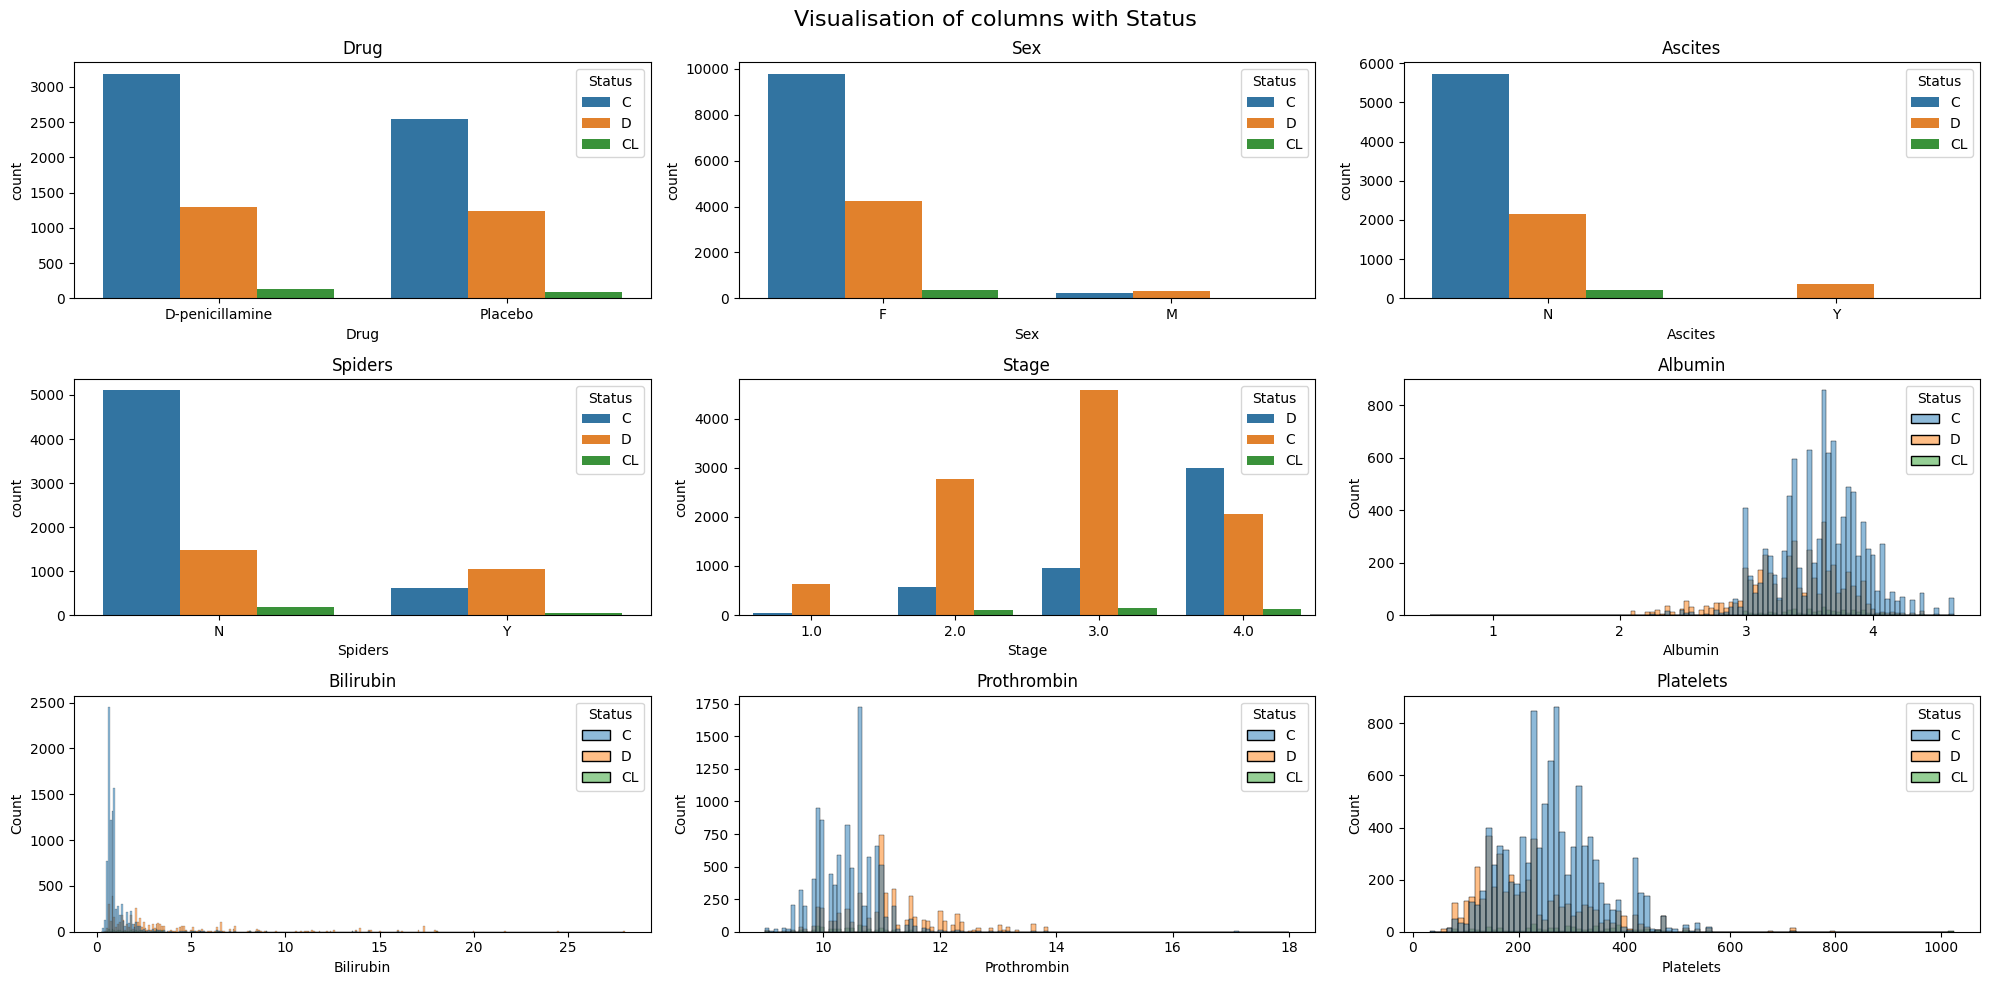

In [9]:
fig, axes = plt.subplots(3,3, figsize = (20,10))
fig.suptitle('Visualisation of columns with Status', fontsize = 16)
sns.countplot(data = df, x= 'Drug', hue = 'Status', ax = axes[0,0])
sns.countplot(data = df, x= 'Sex', hue = 'Status', ax = axes[0,1])
sns.countplot(data = df, x= 'Ascites', hue = 'Status', ax = axes[0,2])
sns.countplot(data = df, x= 'Spiders', hue = 'Status', ax = axes[1,0])
sns.countplot(data = df, x= 'Stage', hue = 'Status', ax = axes[1,1])
sns.histplot(data = df, x= 'Albumin', hue = 'Status', ax = axes[1,2])
sns.histplot(data = df, x= 'Bilirubin', hue = 'Status', ax = axes[2,0])
sns.histplot(data = df, x= 'Prothrombin', hue = 'Status', ax = axes[2,1])
sns.histplot(data = df, x= 'Platelets', hue = 'Status', ax = axes[2,2])

axes[0,0].set_title('Drug')
axes[0,1].set_title('Sex')
axes[0,2].set_title('Ascites')
axes[1,0].set_title('Spiders')
axes[1,1].set_title('Stage')
axes[1,2].set_title('Albumin')
axes[2,0].set_title('Bilirubin')
axes[2,1].set_title('Prothrombin')
axes[2,2].set_title('Platelets')

plt.tight_layout()
plt.show()

##Train and test split

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
X = df.drop(['Status'], axis = 1)
y = df['Status']

# Encode target variable y to numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify = y_encoded, test_size=0.2, random_state=42)

###Scaler with pipeline

In [14]:
from sklearn.pipeline import Pipeline

In [15]:
num = X_train.select_dtypes(include='number').columns
string = X_train.select_dtypes(include='object').columns

num_pipeline = Pipeline([
    ('mean', SimpleImputer(strategy='mean')),
    ('numeric', StandardScaler()),
])


cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

full_pipeline = ColumnTransformer(
    [('numeric', num_pipeline, num),
     ('string', cat_pipeline, string)]
)
X_train_scaled = full_pipeline.fit_transform(X_train)
X_test_scaled = full_pipeline.transform(X_test)

X_train_scaled[:2]

array([[ 1.60089316e+00,  2.54334933e-01, -3.55530149e-01,
        -3.28924990e-02, -5.97450733e-01,  3.33470418e-01,
         3.59687108e+00, -1.12097206e+00,  9.07041952e-01,
         1.28001442e+00,  1.32738294e+00,  1.11954792e+00,
         0.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-6.73229683e-01,  8.88843139e-01, -4.67053096e-01,
         0.00000000e+00, -6.24140880e-01, -2.53230284e-16,
        -1.69527725e-16,  3.19672955e-16,  0.00000000e+00,
        -5.01617749e-02,  5.10427006e-01, -1.18092454e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

##Decision Tree

In [25]:
param_grid = {'min_samples_leaf':np.arange(2,20)}
tree_gscv = GridSearchCV(DecisionTreeClassifier(min_samples_split=14,class_weight='balanced', random_state = 42),
                         param_grid=param_grid,
                         scoring = 'neg_log_loss',
                         cv = 5)
tree_gscv.fit(X_train_scaled, y_train)
tree_gscv.best_params_

{'min_samples_leaf': np.int64(19)}

In [62]:
tree = DecisionTreeClassifier(min_samples_split=14, min_samples_leaf = 19, class_weight='balanced', random_state=42)
tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=19,
                       min_samples_split=14, random_state=42)

In [63]:
y_pred = tree.predict(X_test_scaled)
y_prob = tree.predict_proba(X_test_scaled)

def scores(Y_test, y_pred, y_prob):
  loss = log_loss(y_test, y_prob)
  accuracy = accuracy_score(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(loss)
  print(accuracy)
  print(class_report)


scores(y_test, y_pred, y_prob)

1.700948559160946
0.7112370790263421
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      2010
           1       0.11      0.66      0.19        76
           2       0.68      0.71      0.69       913

    accuracy                           0.71      2999
   macro avg       0.56      0.69      0.56      2999
weighted avg       0.82      0.71      0.75      2999



##Random Forest

In [28]:
param_grid = {'n_estimators':np.arange(100, 500, 50)}
rf_gscv = GridSearchCV(RandomForestClassifier(random_state=42, class_weight = 'balanced'), param_grid=param_grid, scoring='neg_log_loss', cv=5)
rf_gscv.fit(X_train_scaled, y_train)
rf_gscv.best_params_

{'n_estimators': np.int64(450)}

In [64]:
rf_model = RandomForestClassifier(random_state = 42, n_estimators = 450, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=450,
                       random_state=42)

In [65]:
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)

def scores(Y_test, y_pred, y_prob):
  loss = log_loss(y_test, y_prob)
  accuracy = accuracy_score(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(loss)
  print(accuracy)
  print(class_report)


scores(y_test, y_pred, y_prob)

0.40218689229786153
0.8426142047349117
              precision    recall  f1-score   support

           0       0.86      0.94      0.89      2010
           1       0.30      0.04      0.07        76
           2       0.81      0.70      0.75       913

    accuracy                           0.84      2999
   macro avg       0.66      0.56      0.57      2999
weighted avg       0.83      0.84      0.83      2999



##KNN

In [31]:
param_grid = {'n_neighbors':np.arange(1,30)}
knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, scoring='neg_log_loss', cv=5)
knn_gscv.fit(X_train_scaled, y_train)
knn_gscv.best_params_

{'n_neighbors': np.int64(29)}

In [16]:
knn = KNeighborsClassifier(n_neighbors = 29)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=29)

In [17]:
y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)

def scores(Y_test, y_pred, y_prob):
  loss = log_loss(y_test, y_prob)
  accuracy = accuracy_score(y_test, y_pred)
  class_report = classification_report(y_test, y_pred, zero_division = 0)

  print(loss)
  print(accuracy)
  print(class_report)


scores(y_test, y_pred, y_prob)

0.8023222378313954
0.8276092030676893
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      2010
           1       0.00      0.00      0.00        76
           2       0.84      0.61      0.71       913

    accuracy                           0.83      2999
   macro avg       0.56      0.52      0.53      2999
weighted avg       0.81      0.83      0.81      2999



##SVM

In [68]:
svc = SVC(probability = True, random_state=42, class_weight='balanced')
svc.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [69]:
y_pred = svc.predict(X_test_scaled)
y_prob = svc.predict_proba(X_test_scaled)

def scores(Y_test, y_pred, y_prob):
  loss = log_loss(y_test, y_prob)
  accuracy = accuracy_score(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(loss)
  print(accuracy)
  print(class_report)


scores(y_test, y_pred, y_prob)

0.43243289527487894
0.7645881960653551
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      2010
           1       0.13      0.62      0.22        76
           2       0.76      0.73      0.74       913

    accuracy                           0.76      2999
   macro avg       0.59      0.71      0.60      2999
weighted avg       0.83      0.76      0.79      2999



In [70]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1580  231  199]
 [  13   47   16]
 [ 170   77  666]]


##XGBoost

In [37]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_dist = {
    "n_estimators": randint(300, 1200),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.19),      # 0.01 - 0.20
    "subsample": uniform(0.7, 0.3),            # 0.7 - 1.0
    "colsample_bytree": uniform(0.6, 0.4),     # 0.6 - 1.0
    "min_child_weight": randint(1, 8),
    "gamma": uniform(0, 3),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(1, 4)
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_log_loss",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

random_search.fit(X_train_scaled, y_train)

print("Best Log Loss:", -random_search.best_score_)
print("Best Params:", random_search.best_params_)

best_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.749816047538945, gamma=2.8521429192297485, learning_rate=0.14907884894416698, max_depth=7, min_child_weight=5, n_estimators=914, reg_alpha=0.44583275285359114, reg_lambda=1.3998996632720115, subsample=0.8377746675897602; total time=   2.5s
[CV] END colsample_bytree=0.749816047538945, gamma=2.8521429192297485, learning_rate=0.14907884894416698, max_depth=7, min_child_weight=5, n_estimators=914, reg_alpha=0.44583275285359114, reg_lambda=1.3998996632720115, subsample=0.8377746675897602; total time=   2.5s
[CV] END colsample_bytree=0.7334834444556088, gamma=0.42860045376582234, learning_rate=0.13366880986028204, max_depth=7, min_child_weight=2, n_estimators=643, reg_alpha=0.8324426408004217, reg_lambda=1.8493564427131046, subsample=0.7545474901621302; total time=   2.9s
[CV] END colsample_bytree=0.6733618039413735, gamma=0.9127267288786132, learning_rate=0.10970372201012518, max_depth=6, min_child_wei

In [71]:
xgb = XGBClassifier(n_estimators = 798,
                    max_depth = 4,
                    learning_rate = 0.02914,
                    subsample = 0.8967,
                    colsample_bytree = 0.678,
                    min_child_weight = 5,
                    gamma = 0.21,
                    reg_alpha = 0.6182,
                    reg_lambda = 2.346,
                    random_state = 42,
                    objective="multi:softprob",
                    num_class=3,
                    eval_metric="mlogloss",
                    n_jobs=-1,
                    tree_method="hist"
                    )
# Fit XGBoost directly on the numerically encoded y_train
xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.678, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.21,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02914, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=798, n_jobs=-1, num_class=3, ...)

In [72]:
y_pred = xgb.predict(X_test_scaled)
y_prob = xgb.predict_proba(X_test_scaled)

def scores(Y_test_numerical, y_pred, y_prob):
  # Y_test_numerical is now 0, 1, 2
  # Convert Y_test_numerical to one-hot for log_loss calculation
  Y_test_onehot = pd.get_dummies(Y_test_numerical)

  loss = log_loss(Y_test_onehot, y_prob)
  accuracy = accuracy_score(Y_test_numerical, y_pred)
  class_report = classification_report(Y_test_numerical, y_pred)

  print(loss)
  print(accuracy)
  print(class_report)


scores(y_test, y_pred, y_prob)

0.3597730471387162
0.8552850950316773
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      2010
           1       0.68      0.20      0.31        76
           2       0.82      0.74      0.78       913

    accuracy                           0.86      2999
   macro avg       0.79      0.62      0.66      2999
weighted avg       0.85      0.86      0.85      2999



#Test set

In [73]:
df_test = pd.read_csv('/kaggle/input/competitions/multiclassificationtask/test.csv')
df_test

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,15000,22646.0,NaN,22646.0,F,NaN,NaN,NaN,N,1.4,NaN,3.34,NaN,NaN,NaN,NaN,190.0,11.0,4.0
1,15001,2149.0,NaN,18993.0,F,NaN,NaN,NaN,N,0.9,NaN,3.24,NaN,NaN,NaN,NaN,233.0,9.0,2.0
2,15002,3850.0,D-penicillamine,16050.0,M,N,N,N,N,1.0,460.0,3.64,75.0,2148.0,102.30,118.0,172.0,10.6,3.0
3,15003,2419.0,D-penicillamine,20354.0,F,N,N,N,N,0.6,258.0,3.96,31.0,642.0,70.00,83.0,336.0,10.8,2.0
4,15004,1086.0,NaN,23376.0,F,NaN,NaN,NaN,N,4.4,NaN,4.40,NaN,NaN,NaN,NaN,447.0,10.3,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,2106.0,Placebo,16728.0,F,N,N,N,N,1.1,1128.0,3.35,91.0,815.0,127.10,166.0,421.0,9.6,1.0
9996,24996,186.0,D-penicillamine,13073.0,M,N,Y,N,N,0.6,267.0,3.02,225.0,728.0,120.90,90.0,142.0,12.3,4.0
9997,24997,3458.0,D-penicillamine,20296.0,F,N,N,N,N,0.9,NaN,3.35,136.0,1995.0,128.00,NaN,243.0,10.6,2.0
9998,24998,2891.0,D-penicillamine,20254.0,F,N,N,N,N,0.8,NaN,3.75,63.0,674.0,26.35,NaN,325.0,10.0,1.0


In [74]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   N_Days         10000 non-null  float64
 2   Drug           5602 non-null   object 
 3   Age            10000 non-null  float64
 4   Sex            10000 non-null  object 
 5   Ascites        5609 non-null   object 
 6   Hepatomegaly   5598 non-null   object 
 7   Spiders        5596 non-null   object 
 8   Edema          10000 non-null  object 
 9   Bilirubin      10000 non-null  float64
 10  Cholesterol    4353 non-null   float64
 11  Albumin        10000 non-null  float64
 12  Copper         5531 non-null   float64
 13  Alk_Phos       5597 non-null   float64
 14  SGOT           5594 non-null   float64
 15  Tryglicerides  4320 non-null   float64
 16  Platelets      9618 non-null   float64
 17  Prothrombin    9991 non-null   float64
 18  Stage  

##Data preprocessing

In [75]:
df_test.duplicated().sum()

np.int64(0)

In [76]:
df_x = df_test.drop('id', axis = 1)

In [77]:
df_x.shape


(10000, 18)

##Scaler and Imputer

In [78]:
num = X_train.select_dtypes(include='number').columns
string = X_train.select_dtypes(include='object').columns

num_pipeline = Pipeline([
    ('mean', SimpleImputer(strategy='mean')),
    ('numeric', StandardScaler()),
])


cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

full_pipeline = ColumnTransformer(
    [('numeric', num_pipeline, num),
     ('string', cat_pipeline, string)]
)
test_scaled = full_pipeline.fit_transform(df_x)
test_scaled[:2]


array([[ 1.48370890e+01,  8.25193660e-01, -1.63519609e-01,
         0.00000000e+00, -4.74441344e-01,  2.63544449e-16,
         0.00000000e+00,  7.49150780e-17, -4.35911991e-16,
        -6.47771397e-01,  4.96809938e-01,  1.11214911e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.23155772e-01, -9.02268863e-02, -3.39241335e-01,
         0.00000000e+00, -7.39037092e-01,  2.63544449e-16,
         0.00000000e+00,  7.49150780e-17, -4.35911991e-16,
        -2.20611833e-01, -2.21585160e+00, -1.15615419e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

##XGBoost probabilities

In [79]:
test_prob = xgb.predict_proba(test_scaled)

df_result = pd.DataFrame({'id' : df_test['id'],
                          'Status_C' : test_prob[:,0],
                          'Status_CL' : test_prob[:,1],
                          'Status_D' : test_prob[:,2]})
df_result

,id,Status_C,Status_CL,Status_D
0,15000,0.790659,0.005995,0.203346
1,15001,0.740600,0.023839,0.235561
2,15002,0.808942,0.010565,0.180493
3,15003,0.981632,0.001676,0.016693
4,15004,0.571994,0.092048,0.335958
...,...,...,...,...
9995,24995,0.836644,0.085083,0.078273
9996,24996,0.040049,0.031713,0.928238
9997,24997,0.887883,0.005912,0.106205
9998,24998,0.980364,0.001274,0.018363


##Submission file

In [85]:
df_result.to_csv('submission.csv', index=False)